In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [25]:
import pandas as pd

df = pd.read_csv(r"D:\Internship project\spotify dataset.csv",encoding="latin1"
)
df
print(df.head())

                        Track                    Album Name          Artist  \
0         MILLION DOLLAR BABY  Million Dollar Baby - Single   Tommy Richman   
1                 Not Like Us                   Not Like Us  Kendrick Lamar   
2  i like the way you kiss me    I like the way you kiss me         Artemas   
3                     Flowers              Flowers - Single     Miley Cyrus   
4                     Houdini                       Houdini          Eminem   

  Release Date          ISRC All Time Rank  Track Score Spotify Streams  \
0    4/26/2024  QM24S2402528             1        725.4    39,04,70,936   
1   05-04-2024  USUG12400910             2        545.9    32,37,03,884   
2    3/19/2024  QZJ842400387             3        538.4    60,13,09,283   
3   01-12-2023  USSM12209777             4        444.9  2,03,12,80,633   
4    5/31/2024  USUG12403398             5        423.3    10,70,34,922   

  Spotify Playlist Count Spotify Playlist Reach  Spotify Popularity  
0   

In [6]:
print(df.tail())

                                Track                        Album Name  \
4595                For the Last Time                 For the Last Time   
4596                 Dil Meri Na Sune  Dil Meri Na Sune (From "Genius")   
4597            Grace (feat. 42 Dugg)                           My Turn   
4598              Nashe Si Chadh Gayi             November Top 10 Songs   
4599  Me Acostumbre (feat. Bad Bunny)   Me Acostumbre (feat. Bad Bunny)   

            Artist Release Date          ISRC All Time Rank  Track Score  \
4595   $uicideboy$   09-05-2017  QM8DG1703420         4,585         19.4   
4596    Atif Aslam    7/27/2018  INT101800122         4,575         19.4   
4597      Lil Baby    2/28/2020  USUG12000043         4,571         19.4   
4598  Arijit Singh   11-08-2016  INY091600067         4,591         19.4   
4599     Arcï¿½ï¿½   04-11-2017  USB271700107         4,593         19.4   

     Spotify Streams Spotify Playlist Count Spotify Playlist Reach  \
4595    30,50,49,963  

In [7]:
df.describe()

,Track Score,Spotify Popularity
count,4600.000000,3796.000000
mean,41.844043,63.501581
std,38.543766,16.186438
min,19.400000,1.000000
25%,23.300000,61.000000
50%,29.900000,67.000000
75%,44.425000,73.000000
max,725.400000,96.000000


In [8]:
print(df.columns)

Index(['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC',
       'All Time Rank', 'Track Score', 'Spotify Streams',
       'Spotify Playlist Count', 'Spotify Playlist Reach',
       'Spotify Popularity'],
      dtype='str')


In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Track                   4600 non-null   str    
 1   Album Name              4600 non-null   str    
 2   Artist                  4595 non-null   str    
 3   Release Date            4600 non-null   str    
 4   ISRC                    4600 non-null   str    
 5   All Time Rank           4600 non-null   str    
 6   Track Score             4600 non-null   float64
 7   Spotify Streams         4487 non-null   str    
 8   Spotify Playlist Count  4530 non-null   str    
 9   Spotify Playlist Reach  4528 non-null   str    
 10  Spotify Popularity      3796 non-null   float64
dtypes: float64(2), str(9)
memory usage: 395.4 KB
None


In [10]:
print(df.isnull().sum())

Track                       0
Album Name                  0
Artist                      5
Release Date                0
ISRC                        0
All Time Rank               0
Track Score                 0
Spotify Streams           113
Spotify Playlist Count     70
Spotify Playlist Reach     72
Spotify Popularity        804
dtype: int64


In [14]:
df.drop_duplicates(inplace=True)
#df.dropna(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (3778, 11)


In [15]:
numeric_columns = [
    "Spotify Streams",
    "Spotify Playlist Count",
    "Spotify Playlist Reach"
]

for col in numeric_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [16]:
df["Track Score"] = pd.to_numeric(df["Track Score"], errors="coerce")

df["Spotify Popularity"] = pd.to_numeric(
    df["Spotify Popularity"],
    errors="coerce"
)

In [17]:
df["Release Date"] = pd.to_datetime(
    df["Release Date"],
    errors="coerce"
)

In [18]:
df.dropna(inplace=True)

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (2143, 11)


In [19]:
print(df.describe())


                     Release Date  Track Score  Spotify Streams  \
count                        2143  2143.000000     2.143000e+03   
mean   2020-12-24 09:35:51.936537    42.496034     4.701286e+08   
min           1987-07-21 00:00:00    19.400000     2.030000e+03   
25%           2019-06-14 00:00:00    23.600000     1.053358e+08   
50%           2021-11-18 00:00:00    30.300000     2.830021e+08   
75%           2023-04-13 00:00:00    45.250000     6.538841e+08   
max           2024-05-31 00:00:00   725.400000     4.281469e+09   
std                           NaN    39.525351     5.246985e+08   

       Spotify Playlist Count  Spotify Playlist Reach  Spotify Popularity  
count             2143.000000            2.143000e+03         2143.000000  
mean             65083.714886            2.477159e+07           63.136724  
min                  1.000000            3.000000e+00            1.000000  
25%              13031.000000            6.386326e+06           60.000000  
50%             

In [20]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 2143 entries, 0 to 4597
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Track                   2143 non-null   str           
 1   Album Name              2143 non-null   str           
 2   Artist                  2143 non-null   str           
 3   Release Date            2143 non-null   datetime64[us]
 4   ISRC                    2143 non-null   str           
 5   All Time Rank           2143 non-null   str           
 6   Track Score             2143 non-null   float64       
 7   Spotify Streams         2143 non-null   int64         
 8   Spotify Playlist Count  2143 non-null   int64         
 9   Spotify Playlist Reach  2143 non-null   int64         
 10  Spotify Popularity      2143 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 200.9 KB
None


In [21]:
print(df.isnull().sum())

Track                     0
Album Name                0
Artist                    0
Release Date              0
ISRC                      0
All Time Rank             0
Track Score               0
Spotify Streams           0
Spotify Playlist Count    0
Spotify Playlist Reach    0
Spotify Popularity        0
dtype: int64


In [22]:
df.to_csv(
    "spotify_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [30]:

df1 = pd.read_csv("spotify_cleaned.csv")


In [31]:
print("Shape:", df1.shape)

Shape: (2143, 11)


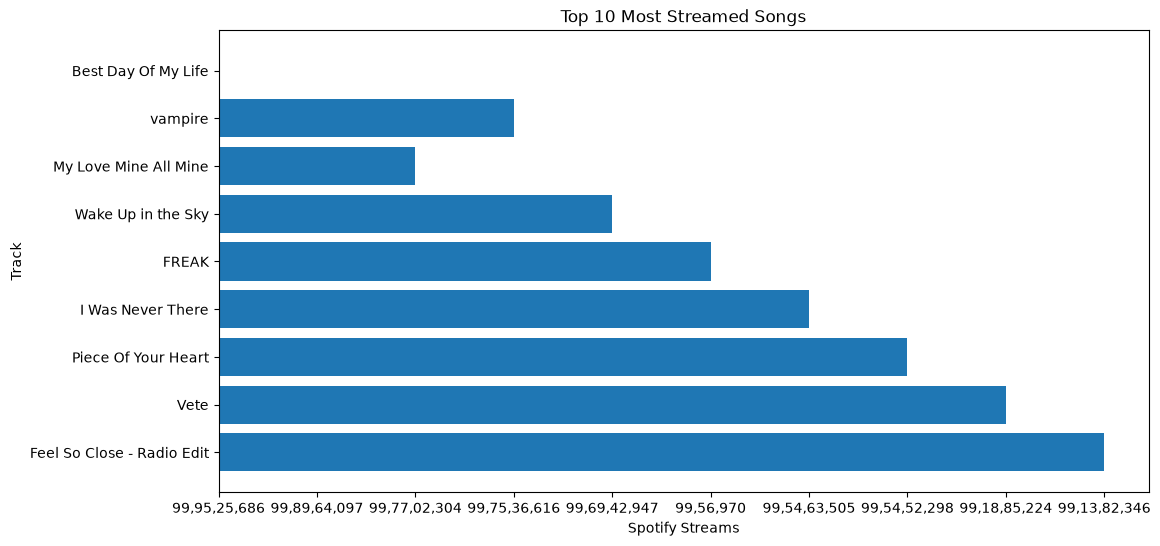

In [32]:
top_songs = df.sort_values(
    by="Spotify Streams",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_songs["Track"],
    top_songs["Spotify Streams"]
)

plt.title("Top 10 Most Streamed Songs")
plt.xlabel("Spotify Streams")
plt.ylabel("Track")
plt.gca().invert_yaxis()

plt.show()

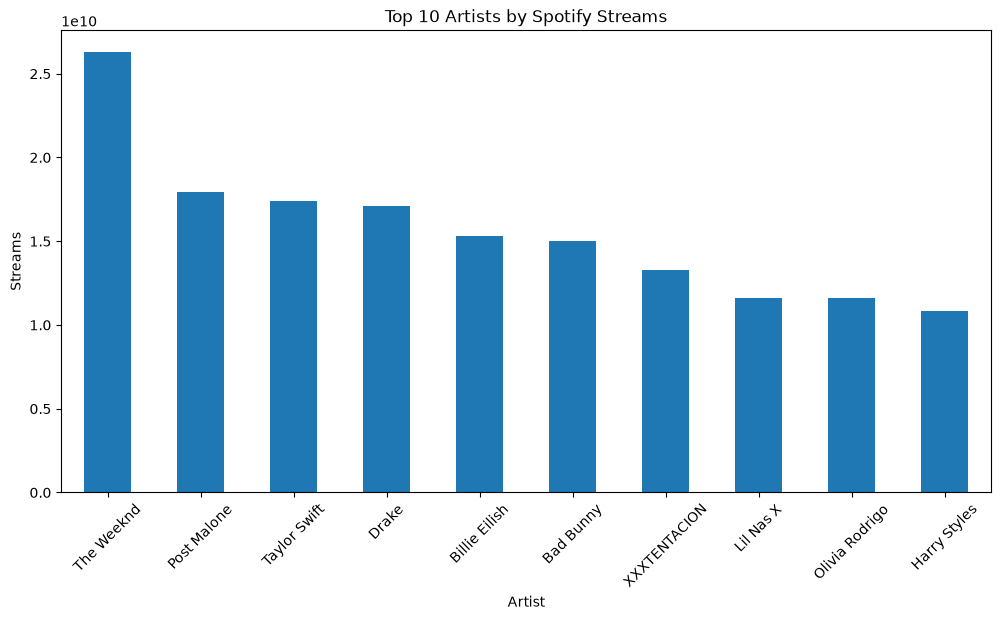

In [36]:
artist_streams = df1.groupby("Artist")["Spotify Streams"].sum()

top_artists = artist_streams.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_artists.plot(kind="bar")

plt.title("Top 10 Artists by Spotify Streams")

plt.ylabel("Streams")

plt.xticks(rotation=45)

plt.show()

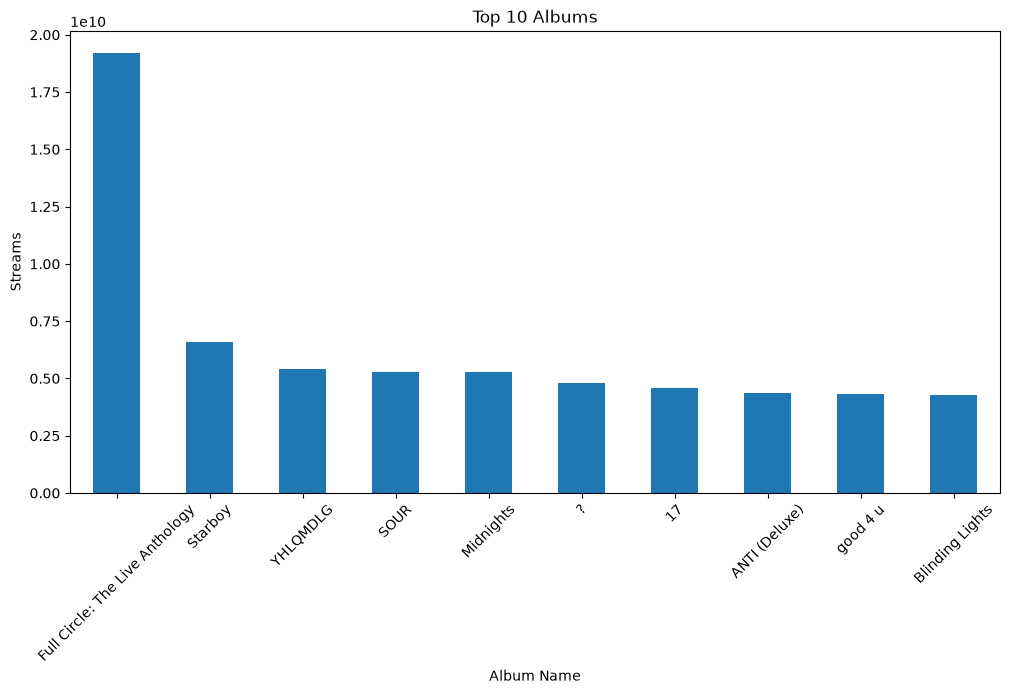

In [37]:
album_streams = df1.groupby("Album Name")["Spotify Streams"].sum()

top_albums = album_streams.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_albums.plot(kind="bar")

plt.title("Top 10 Albums")

plt.ylabel("Streams")

plt.xticks(rotation=45)

plt.show()

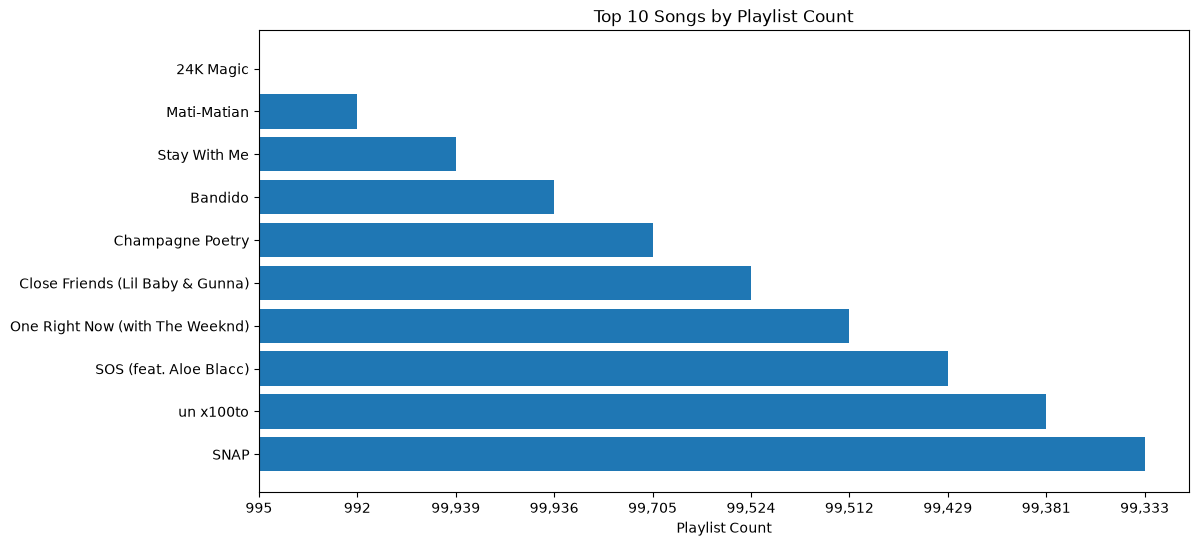

In [38]:
top_playlist = df.sort_values(
    by="Spotify Playlist Count",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_playlist["Track"],
    top_playlist["Spotify Playlist Count"]
)

plt.title("Top 10 Songs by Playlist Count")

plt.xlabel("Playlist Count")

plt.gca().invert_yaxis()

plt.show()

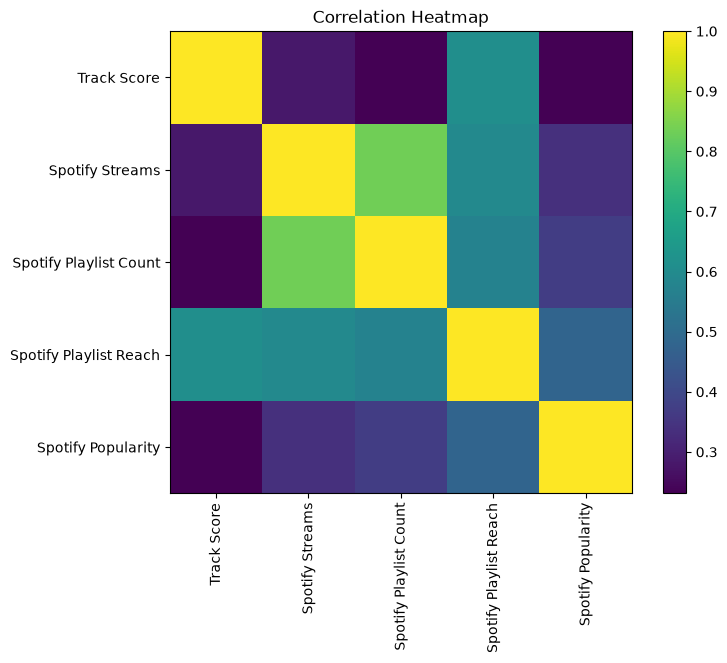

In [47]:
numeric = df1[[
    "Track Score",
    "Spotify Streams",
    "Spotify Playlist Count",
    "Spotify Playlist Reach",
    "Spotify Popularity"
]]

corr = numeric.corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()